# Vascular skin lesions with Ray AI Runtime (AIR)

## Notebook overview

This notebook builds a vascular lesion classifier using Ray AIR:
- Ray Data for parallel image loading and feature extraction.
- Ray Train for SVM training in a reproducible pipeline.
- Ray Tune for lightweight hyperparameter search.

The dataset is small, so image size and tuning budget are kept modest.

## Ray runtime (local vs docker)
If you start the Ray cluster via `deploy/docker-compose.yaml`, the head node exposes port `10001` for Ray client connections.
Set `RAY_ADDRESS` to connect (host machine: `ray://localhost:10001`, container in the same compose network: `ray://ray-head:10001`).
If `RAY_ADDRESS` is unset, this notebook starts a local Ray runtime.

In [16]:
# Imports and configuration
from pathlib import Path
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import ray
from ray import tune
from ray.tune.tuner import Tuner, TuneConfig

import joblib
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler as SkMinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

%matplotlib inline

load_dotenv()

RANDOM_STATE = 42
DATA_DIR = Path("vascular_skin_lesion")
IMG_SIZE = (128, 128)

In [63]:
def summarize_classification(y_true, y_pred, labels):
    print(classification_report(y_true=y_true, y_pred=y_pred, target_names=labels))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.xticks(rotation=45)
    plt.show()

## Baseline SVM (single-thread, raw pixels)
We start with a deliberately simple raw-pixel SVM baseline. This is useful as a sanity check, but it is not directly comparable to the stronger engineered-feature SVM in `classify_skin_cancer_base.ipynb`. The comparable classical baseline is evaluated after feature extraction.

### Simple SVM with test-train split

In [66]:
records_raw = []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    cls = cls_dir.name
    for img_path in cls_dir.glob("*"):
        try:
            with Image.open(img_path) as im:
                w, h = im.size
        except Exception:
            continue
        records_raw.append({"path": str(img_path), "label": cls, "width": w, "height": h})

if not records_raw:
    raise ValueError(f"No images found under {DATA_DIR.resolve()}")

df = pd.DataFrame(records_raw)
label_names = sorted(df["label"].unique())
label_to_id = {name: idx for idx, name in enumerate(label_names)}
df["label_id"] = df["label"].map(label_to_id)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

In [67]:
print("Total images:", len(df))
print("Class map:", label_to_id)

Total images: 284
Class map: {'nv': 0, 'vasc': 1}


In [18]:
def summarize_cv(cv_results, model_name):
    summary = {"model": model_name}
    for metric in SCORING.keys():
        values = cv_results[f"test_{metric}"]
        summary[f"{metric}_mean"] = float(np.mean(values))
        summary[f"{metric}_std"] = float(np.std(values))
    return pd.DataFrame([summary])

def run_cv(model, X, y, model_name, cv, use_ray=False, n_jobs=None):
    params = {
        "estimator": model,
        "X": X,
        "y": y,
        "cv": cv,
        "scoring": SCORING,
        "n_jobs": n_jobs,
        "error_score": "raise",
    }

    if n_jobs is None:
        n_jobs = -1 if use_ray else 1
    if use_ray:
        with joblib.parallel_backend("ray"):
            results = cross_validate(**params)
    else:
        results = cross_validate(**params)

    summary = summarize_cv(results, model_name)
    return results, summary

def cv_classification_report(model, X, y, cv):
    preds = cross_val_predict(model, X, y, cv=cv, n_jobs=1)
    return classification_report(y, preds, target_names=label_names)

In [19]:
# Single-thread SVM baseline on raw pixels
BASELINE_IMG_SIZE = (64, 64)

def load_image_array(path, size=BASELINE_IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert("RGB").resize(size)
        arr = np.array(im).astype(np.float32) / 255.0
    return arr

In [20]:
X_raw = np.stack([load_image_array(p) for p in df["path"]])
y_raw = df["label_id"].values
X_raw_flat = X_raw.reshape((X_raw.shape[0], -1))

In [21]:
X_raw_train_flat, X_raw_test_flat, y_raw_train, y_raw_test = train_test_split(
    X_raw_flat, y_raw, test_size=0.2, stratify=y_raw, random_state=RANDOM_STATE
)

In [35]:
simple_svm = SVC(kernel="linear", random_state=RANDOM_STATE)
simple_svm.fit(X_raw_train_flat, y_raw_train);

Raw-pixel SVM report (test data):
              precision    recall  f1-score   support

          nv       0.97      1.00      0.98        29
        vasc       1.00      0.96      0.98        28

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



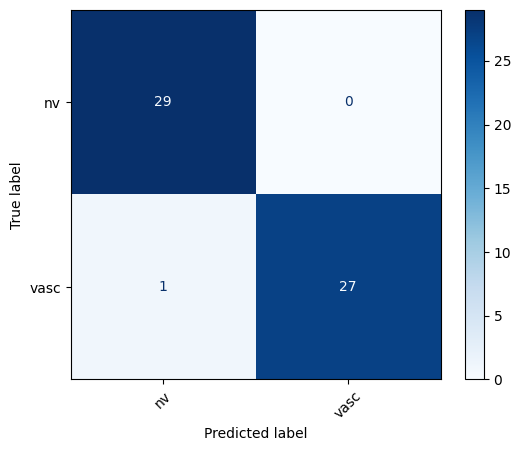

In [65]:
print("Raw-pixel SVM report (test data):")
summarize_classification(y_true=y_raw_test, y_pred=simple_svm.predict(X_raw_test_flat), labels=label_names)

Raw-pixel SVM report (full dataset):
              precision    recall  f1-score   support

          nv       0.99      1.00      1.00       142
        vasc       1.00      0.99      1.00       142

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



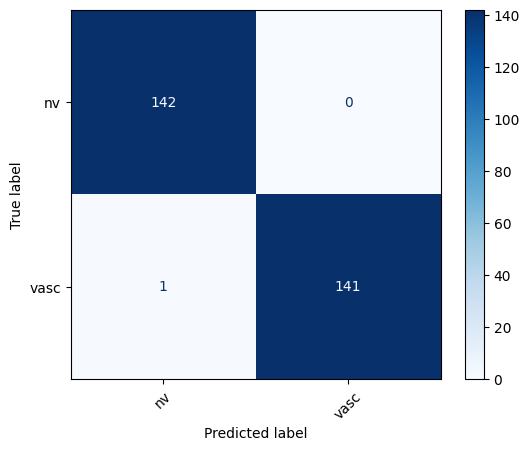

In [68]:
print("Raw-pixel SVM report (full dataset):")
summarize_classification(y_true=y_raw, y_pred=simple_svm.predict(X_raw_flat), labels=label_names)

The classifier performs much bettern than we could expect. This is likely due to the small dataset size which contains only 242 images. Neverthless it is pretty unexpected that the data is almost perfectly linearly separable in the raw pixel space, even without scaling, which is a curcial for SVMs.

### Simple SVM with cross-validation and hyperparameter tuning

Let's check if the good performance will be present with simple SVM with cross-validation. Cross validation is a recommended approach for small datasets, as it allows to use all data for training and testing. We will use 5-fold cross-validation, which is a common choice for small datasets.

In [42]:
baseline_model = Pipeline(
    [
        ("scaler", SkMinMaxScaler(feature_range=(-1, 1))),
        ("svc", SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

In [43]:
simple_svm_grid_params = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": [1, 0.1, 0.01, 0.001, 0.0001],
}

In [53]:
svm_grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=simple_svm_grid_params,
    cv=cv,
    scoring="recall_macro",
    n_jobs=-1,
    error_score="raise",
)
svm_grid_search.fit(X_raw_train_flat, y_raw_train);

In [56]:
simple_svm_best_model = svm_grid_search.best_estimator_

Raw-pixel SVM report (full data):
              precision    recall  f1-score   support

          nv       0.99      1.00      1.00       142
        vasc       1.00      0.99      1.00       142

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



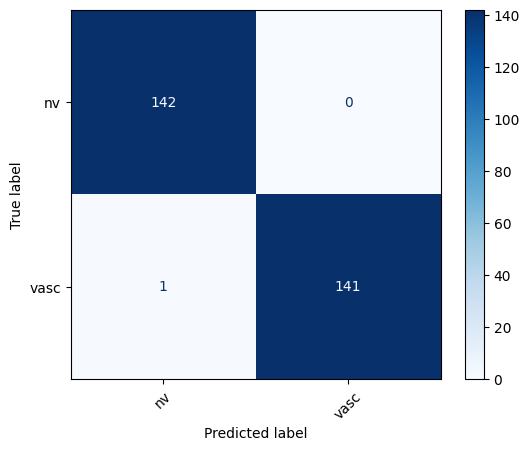

In [69]:
print("Raw-pixel SVM report (full data):")
summarize_classification(y_true=y_raw, y_pred=simple_svm_best_model.predict(X_raw_flat), labels=label_names)

## SVM model training with computer vision features

Let's see if extracting features vith computer vision techniques can give the same results or improve the model performance.

In [ ]:
if ray.is_initialized():
    ray.shutdown()

ray_address = os.getenv("RAY_ADDRESS", "").strip()
if ray_address:
    ray.init(address=ray_address)
else:
    ray.init(object_store_memory=1.5 * 1024 * 1024 * 1024)

In [ ]:
# Build an index of image paths and labels for Ray Data
ray_records = df[["path", "label_id"]].rename(columns={"label_id": "label"}).to_dict(orient="records")

img_ds = ray.data.from_items(ray_records).random_shuffle(seed=RANDOM_STATE)

print("Total images:", len(ray_records))
print("Class map:", label_to_id)

In [ ]:
# Quick dataset analysis and samples
print("Class counts:")
print(df["label"].value_counts().reindex(label_names))

sample = df.sample(min(6, len(df)), random_state=RANDOM_STATE)
cols = 3
rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes[len(sample):]:
    ax.axis("off")

for i, (_, r) in enumerate(sample.iterrows()):
    img = Image.open(r["path"]).convert("RGB")
    ax = axes[i]
    ax.imshow(img.resize(IMG_SIZE))
    ax.set_title(r["label"])
    ax.axis("off")

plt.tight_layout()

In [ ]:
# Preprocessing helpers
def gray_world_balance(img):
    means = img.reshape(-1, 3).mean(axis=0)
    mean_all = means.mean()
    scale = mean_all / (means + 1e-8)
    balanced = img * scale
    return np.clip(balanced, 0.0, 1.0)

def contrast_stretch(img, lo=1, hi=99):
    out = img.copy()
    for c in range(3):
        p_lo, p_hi = np.percentile(out[..., c], [lo, hi])
        if p_hi - p_lo < 1e-6:
            continue
        out[..., c] = (out[..., c] - p_lo) / (p_hi - p_lo)
    return np.clip(out, 0.0, 1.0)

def otsu_threshold(gray):
    hist, _ = np.histogram(gray.ravel(), bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / (hist.sum() + 1e-12)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.linspace(0.0, 1.0, 256))
    mu_t = mu[-1]
    sigma_b = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    idx = np.nanargmax(sigma_b)
    return idx / 255.0

def binary_erode(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode="constant", constant_values=0)
    eroded = np.ones_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            eroded = np.minimum(eroded, padded[1 + dy : 1 + dy + h, 1 + dx : 1 + dx + w])
    return eroded.astype(bool)

def binary_dilate(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode="constant", constant_values=0)
    dilated = np.zeros_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            dilated = np.maximum(dilated, padded[1 + dy : 1 + dy + h, 1 + dx : 1 + dx + w])
    return dilated.astype(bool)

def clean_mask(mask):
    mask = binary_dilate(binary_erode(mask))
    mask = binary_erode(binary_dilate(mask))
    return mask

def preprocess_image(path, size=IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert("RGB")
        im = im.filter(ImageFilter.MedianFilter(size=3))
        im = im.resize(size)
        img = np.array(im).astype(np.float32) / 255.0
    img = gray_world_balance(img)
    img = contrast_stretch(img)
    gray = img.mean(axis=2)
    thresh = otsu_threshold(gray)
    mask = gray < thresh
    if mask.mean() > 0.6:
        mask = ~mask
    mask = clean_mask(mask)
    img_seg = img * mask[..., None]
    return img, img_seg, mask

## Preprocessing and segmentation
We apply a light artifact reduction and color normalization pipeline, then create a coarse lesion mask using Otsu thresholding on the corrected grayscale image.

Pipeline:
- Median filter to suppress thin hair-like artifacts.
- Gray-world color constancy and percentile contrast stretch.
- Otsu threshold on grayscale, with simple morphology to clean the mask.

In [ ]:
# Feature extraction helpers
def hsv_hist_features(img, bins=(16, 8, 8)):
    hsv = Image.fromarray((img * 255).astype(np.uint8)).convert("HSV")
    hsv = np.array(hsv).astype(np.float32)
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]
    h_hist = np.histogram(h, bins=bins[0], range=(0, 255), density=True)[0]
    s_hist = np.histogram(s, bins=bins[1], range=(0, 255), density=True)[0]
    v_hist = np.histogram(v, bins=bins[2], range=(0, 255), density=True)[0]
    return np.concatenate([h_hist, s_hist, v_hist])

def lbp_hist(gray):
    g = (gray * 255).astype(np.uint8)
    center = g[1:-1, 1:-1]
    lbp = np.zeros_like(center, dtype=np.uint8)
    lbp |= ((g[1:-1, 2:] >= center).astype(np.uint8) << 0)
    lbp |= ((g[:-2, 2:] >= center).astype(np.uint8) << 1)
    lbp |= ((g[:-2, 1:-1] >= center).astype(np.uint8) << 2)
    lbp |= ((g[:-2, :-2] >= center).astype(np.uint8) << 3)
    lbp |= ((g[1:-1, :-2] >= center).astype(np.uint8) << 4)
    lbp |= ((g[2:, :-2] >= center).astype(np.uint8) << 5)
    lbp |= ((g[2:, 1:-1] >= center).astype(np.uint8) << 6)
    lbp |= ((g[2:, 2:] >= center).astype(np.uint8) << 7)
    hist = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)[0]
    return hist

def shape_features(mask):
    if mask.sum() == 0:
        return np.zeros(6, dtype=np.float32)
    ys, xs = np.where(mask)
    area = float(mask.sum())
    boundary = mask & ~binary_erode(mask)
    perimeter = float(boundary.sum())
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    bbox_area = float((y1 - y0 + 1) * (x1 - x0 + 1))
    aspect = (x1 - x0 + 1) / (y1 - y0 + 1)
    extent = area / bbox_area
    ys_c = ys - ys.mean()
    xs_c = xs - xs.mean()
    cov = np.cov(np.vstack([ys_c, xs_c]))
    eig = np.sort(np.linalg.eigvals(cov))
    ecc = 0.0
    if eig[1] > 0:
        ecc = float(np.sqrt(1.0 - eig[0] / eig[1]))
    compact = (perimeter ** 2) / (area + 1e-8)
    return np.array([area, perimeter, aspect, extent, compact, ecc], dtype=np.float32)

def intensity_features(gray, mask):
    if mask.sum() == 0:
        return np.zeros(2, dtype=np.float32)
    vals = gray[mask]
    return np.array([vals.mean(), vals.std()], dtype=np.float32)

def extract_features(path, size=IMG_SIZE):
    img, img_seg, mask = preprocess_image(path, size=size)
    gray = img_seg.mean(axis=2)
    feats = [
        hsv_hist_features(img_seg),
        lbp_hist(gray),
        shape_features(mask),
        intensity_features(gray, mask),
    ]
    return np.concatenate(feats)

feat_example = extract_features(df["path"].iloc[0])
FEATURE_LEN = int(feat_example.shape[0])
FEATURE_COLUMNS = [f"f{i}" for i in range(FEATURE_LEN)]

HSV_LEN = 16 + 8 + 8
LBP_LEN = 256
SHAPE_LEN = 6
INT_LEN = 2
FEATURE_GROUPS = {
    "hsv": list(range(0, HSV_LEN)),
    "lbp": list(range(HSV_LEN, HSV_LEN + LBP_LEN)),
    "shape": list(range(HSV_LEN + LBP_LEN, HSV_LEN + LBP_LEN + SHAPE_LEN)),
    "intensity": list(range(HSV_LEN + LBP_LEN + SHAPE_LEN, FEATURE_LEN)),
}
print("Feature length:", FEATURE_LEN)

## Ray Data: featurize the dataset
We use Ray Data to parallelize feature extraction across images and produce a tabular dataset with one row per image.

In [ ]:
# Featurize with Ray Data
def featurize_item(item):
    try:
        feat = extract_features(item["path"])
    except Exception:
        return None
    row = {"label": item["label"]}
    for i, val in enumerate(feat):
        row[f"f{i}"] = float(val)
    return row

feat_ds = img_ds.map(featurize_item).filter(lambda x: x is not None)
feat_ds = feat_ds.repartition(num_blocks=4)

feat_pd = feat_ds.to_pandas()
X_feat = feat_pd[FEATURE_COLUMNS].values
y_feat = feat_pd["label"].values

print("Featurized rows:", len(feat_pd))
print(pd.Series(y_feat).value_counts().sort_index())

## Cross-validation on engineered features
We evaluate the comparable classical SVM baseline on the same HSV/LBP/shape/intensity features used in `classify_skin_cancer_base.ipynb`, now at the same 128x128 preprocessing size. We also compare SVM+PCA, Random Forest, and Gradient Boosting, and run one SVM CV pass through the Ray Joblib backend.

In [ ]:
from ray.util.joblib import register_ray

register_ray()

In [ ]:
# Cross-validation on engineered features
svm_pipeline = Pipeline(
    [
        ("scaler", SkMinMaxScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
svm_cv_results, svm_summary = run_cv(
    svm_pipeline,
    X_feat,
    y_feat,
    "svm_features_default",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)

# Match the stronger base-notebook SVM search space.
svm_param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1.0],
}
svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    error_score="raise",
)
svm_grid.fit(X_feat, y_feat)
print("Best sklearn SVM params:", svm_grid.best_params_)
print("Best sklearn SVM CV f1_macro:", svm_grid.best_score_)

svm_tuned_pipeline = svm_grid.best_estimator_
svm_tuned_cv_results, svm_tuned_summary = run_cv(
    svm_tuned_pipeline,
    X_feat,
    y_feat,
    "svm_features_grid_tuned",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)

svm_ray_results, svm_ray_summary = run_cv(
    svm_tuned_pipeline,
    X_feat,
    y_feat,
    "svm_features_grid_tuned_ray",
    cv=cv,
    use_ray=True,
    n_jobs=-1,
)

svm_pca_pipeline = Pipeline(
    [
        ("scaler", SkMinMaxScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
svm_pca_results, svm_pca_summary = run_cv(
    svm_pca_pipeline,
    X_feat,
    y_feat,
    "svm_pca_features",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
 )
rf_results, rf_summary = run_cv(
    rf_model,
    X_feat,
    y_feat,
    "random_forest",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)

gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_results, gb_summary = run_cv(
    gb_model,
    X_feat,
    y_feat,
    "gradient_boosting",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)

cv_summary = pd.concat(
    [
        svm_summary,
        svm_tuned_summary,
        svm_pca_summary,
        rf_summary,
        gb_summary,
        svm_ray_summary,
    ],
    ignore_index=True,
)
cv_summary

model_registry = {
    "svm_features_default": svm_pipeline,
    "svm_features_grid_tuned": svm_tuned_pipeline,
    "svm_pca_features": svm_pca_pipeline,
    "random_forest": rf_model,
    "gradient_boosting": gb_model,
}

## Ray Tune: hyperparameter search with CV
We run the same base-style SVM grid through Ray Tune so the distributed search is comparable to the single-thread grid baseline instead of relying on a tiny random sample.

In [ ]:
# Ray Tune: CV-based SVM search
def train_svm_tune(config, X, y, n_splits, seed):
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for train_idx, val_idx in splitter.split(X, y):
        model = Pipeline(
            [
                ("scaler", SkMinMaxScaler()),
                (
                    "svc",
                    SVC(
                        C=config["C"],
                        gamma=config["gamma"],
                        kernel="rbf",
                        class_weight="balanced",
                        random_state=seed,
                    ),
                ),
            ]
        )
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], pred, average="macro"))
    tune.report({"f1_macro": float(np.mean(scores)), "f1_std": float(np.std(scores))})

param_space = {
    "C": tune.grid_search([0.1, 1, 10, 100]),
    "gamma": tune.grid_search(["scale", 0.01, 0.1, 1.0]),
}

tuner = Tuner(
    tune.with_parameters(
        train_svm_tune,
        X=X_feat,
        y=y_feat,
        n_splits=cv.get_n_splits(),
        seed=RANDOM_STATE,
    ),
    param_space=param_space,
    tune_config=TuneConfig(metric="f1_macro", mode="max"),
)

result_grid = tuner.fit()
best_result = result_grid.get_best_result()
best_config = best_result.config

print("Best Ray Tune config:", best_config)
print("Best Ray Tune CV f1_macro:", best_result.metrics["f1_macro"])

## Tuned SVM evaluation (CV)
We evaluate the tuned SVM configuration with the same stratified K-fold CV protocol.

In [ ]:
# Evaluate tuned SVM with CV
best_model = Pipeline(
    [
        ("scaler", SkMinMaxScaler()),
        (
            "svc",
            SVC(
                C=best_config["C"],
                gamma=best_config["gamma"],
                kernel="rbf",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

tuned_results, tuned_summary = run_cv(
    best_model,
    X_feat,
    y_feat,
    "svm_tuned",
    cv=cv,
    use_ray=False,
    n_jobs=1,
)
tuned_summary
print("Tuned SVM CV report:")
print(cv_classification_report(best_model, X_feat, y_feat, cv=cv))

tuned_preds = cross_val_predict(best_model, X_feat, y_feat, cv=cv, n_jobs=1)
cm = confusion_matrix(y_feat, tuned_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.show()

## Feature analysis
We inspect tree-based feature importances and permutation importance, grouped by feature blocks.

In [ ]:
# Feature importance analysis using tree models
tree_candidates = ["random_forest", "gradient_boosting"]
tree_summary = cv_summary[cv_summary["model"].isin(tree_candidates)].copy()
if tree_summary.empty:
    raise ValueError("No tree-based models available for feature analysis.")

best_tree_name = tree_summary.sort_values("f1_macro_mean", ascending=False).iloc[0]["model"]
best_tree_model = model_registry[best_tree_name]

best_tree_model.fit(X_feat, y_feat)
importances = best_tree_model.feature_importances_
importance_sum = float(np.sum(importances))
feature_importance_df = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "importance": importances}
).sort_values("importance", ascending=False)

print("Best tree model for feature analysis:", best_tree_name)
print("Feature importance sum:", importance_sum)
print("Top features (tree importance):")
print(feature_importance_df.head(20).to_string(index=False))

group_rows = []
for group, idxs in FEATURE_GROUPS.items():
    group_rows.append({"group": group, "importance": float(np.sum(importances[idxs]))})
group_importance_df = pd.DataFrame(group_rows).sort_values("importance", ascending=False)
print("Grouped importance (tree):")
print(group_importance_df.to_string(index=False))

train_idx, test_idx = next(cv.split(X_feat, y_feat))
perm_model = clone(best_tree_model)
perm_model.fit(X_feat[train_idx], y_feat[train_idx])
perm = permutation_importance(
    perm_model,
    X_feat[test_idx],
    y_feat[test_idx],
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
)
perm_df = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "importance": perm.importances_mean}
).sort_values("importance", ascending=False)
print("Top features (permutation importance):")
print(perm_df.head(20).to_string(index=False))

perm_group_rows = []
for group, idxs in FEATURE_GROUPS.items():
    perm_group_rows.append(
        {"group": group, "importance": float(np.sum(perm.importances_mean[idxs]))}
    )
perm_group_df = pd.DataFrame(perm_group_rows).sort_values("importance", ascending=False)
print("Grouped importance (permutation):")
print(perm_group_df.to_string(index=False))

In [ ]:
ray.shutdown()